Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
anomaly
 1    15176
-1      799
Name: count, dtype: int64


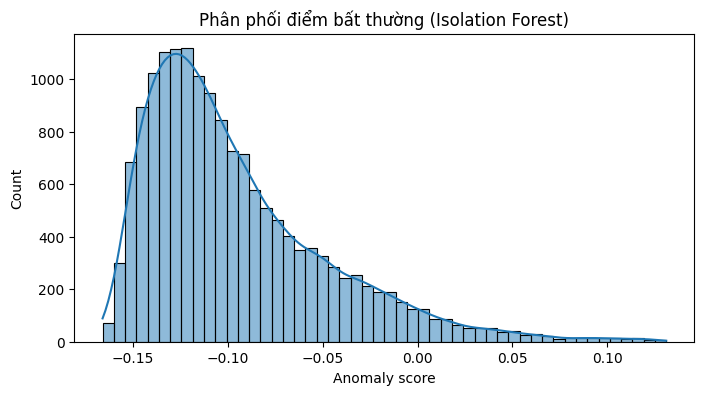

       BEARER_MME_UTIL  CREATE_DEDICATED_BEARER_SR  CSFB SR  \
67               15.53                       98.77   100.00   
61               15.46                      100.00   100.00   
66               15.48                       99.21    99.44   
65               15.50                       99.06   100.00   
14224            18.17                       98.92    98.67   
50               15.37                       93.85   100.00   
64               15.49                      100.00   100.00   
192              16.67                       98.03    99.55   
14230            17.99                       98.02    98.90   
58               15.39                       98.77   100.00   

       DEDICATED_BEARER_MME   EASR  INTRA_TAU_SR  S1_INTRA_HANDOVER_SR  \
67                      270  97.10         99.97                 37.89   
61                      286  96.87         99.97                 42.95   
66                      281  96.70         99.97                 38.93   
65        

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/data_hl19.csv"

#1. Đọc dữ liệu
data = pd.read_csv(path)
# CONFIG

MODEL_TYPE = "IF"
N_COMPONENTS = 5
TEST_SIZE = 0.2
EPOCHS = 30
K_CLUSTERS = 3


#2. Loại bỏ cột không cần
feature_drop = ['PGW BEARER SR', 'date']
data.drop(columns=feature_drop, inplace=True)

#3. Xác định X, y
X = data.drop('SGW BEARER SR', axis=1)
y = data['SGW BEARER SR']



#4. Giảm chiều bằng PCA
pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X)
X = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])

#5. Chuẩn hoá dữ liệu
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

if MODEL_TYPE == "LSTM":
    # Tách tập train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=TEST_SIZE, random_state=42)

    # Reshape dữ liệu 3D cho LSTM
    X_train = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
    X_test = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

    # Tạo model
    model = Sequential([
        LSTM(128, activation='relu', input_shape=(1, X_train.shape[2]), return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Huấn luyện
    history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32,
                        validation_data=(X_test, y_test), verbose=1)

    # Đánh giá
    loss, mae = model.evaluate(X_test, y_test)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test MAE: {mae:.4f}")

    # Dự đoán và trực quan
    y_pred = model.predict(X_test)
    plt.plot(y_test.values, label='True')
    plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.title("LSTM Prediction vs True Values")
    plt.show()


elif MODEL_TYPE == "KMEANS":
    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    sil_score = silhouette_score(X, cluster_labels)
    print(f"Silhouette Score (K={K_CLUSTERS}): {sil_score:.4f}")

    plt.scatter(X['PC1'], X['PC2'], c=cluster_labels, cmap='viridis')
    plt.title("KMeans Clustering with PCA")
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()


elif MODEL_TYPE == "IF": # ISOLATION FOREST
    iso = IsolationForest( n_estimators=100,contamination=0.05,random_state=42)
    iso.fit(X)
    y_pred = iso.fit_predict(X)
    data['anomaly'] = y_pred
    data['score'] = iso.decision_function(X) * -1

    print(data['anomaly'].value_counts())
    plt.figure(figsize=(8,4))
    sns.histplot(data['score'], bins=50, kde=True)
    plt.title('Phân phối điểm bất thường (Isolation Forest)')
    plt.xlabel('Anomaly score')
    plt.show()

    top_anomalies = data.sort_values('score', ascending=False).head(10)
    print(top_anomalies)



